# Gradient descent from scratch: GD -> SGD -> RMSprop -> Adam

Four optimizers, written in plain numpy, one small step at a time.

They all share the same skeleton:

```
repeat:
    g = gradient of the loss at the current w
    w = w - (some step built from g)
```

and differ only in **which data the gradient is computed on** and **how the step
is built from it**:

| method  | gradient from | step |
|---------|---------------|------|
| GD      | the whole dataset | `lr * g` |
| SGD     | a random mini-batch | `lr * g` |
| RMSprop | a random mini-batch | `lr * g / sqrt(EMA of g^2)` |
| Adam    | a random mini-batch | `lr * (EMA of g) / sqrt(EMA of g^2)` |

Every function is pure numpy. Matplotlib shows up only at the very end, to draw
the loss curves and the trajectories.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0

## 0. The problem we are going to minimize

To watch an optimizer work we need a loss whose gradient we can write down by
hand. Linear regression with mean squared error is the classic choice: it is
convex, so there is exactly one minimum and no local traps to blame for a bad
run.

Model and loss (`n` samples, `X` already contains a column of ones for the bias,
so the intercept is just one more weight and every formula stays a clean matrix
product):

```
y_hat = X @ w
L(w)  = (1/n) * sum_i (x_i . w - y_i)^2
```

Gradient (chain rule on the square):

```
dL/dw = (2/n) * X^T (X @ w - y)
```

The same formula works for one sample, for a mini-batch and for the full
dataset - only the number of rows in `X` changes. That is what lets all four
optimizers reuse a single `mse_grad`.

In [ ]:
def make_regression_data(n_samples=400, n_features=3, noise=0.5, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n_samples, n_features))
    X = np.hstack([X, np.ones((n_samples, 1))])      # bias trick
    w_true = rng.normal(size=X.shape[1]) * 3.0
    y = X @ w_true + rng.normal(scale=noise, size=n_samples)
    return X, y, w_true


def mse_loss(w, X, y):
    return np.mean((X @ w - y) ** 2)


def mse_grad(w, X, y):
    return 2.0 * X.T @ (X @ w - y) / len(y)

Two more shared helpers.

`iterate_minibatches` covers one pass over the data: reshuffle, then slice.
Reshuffling every epoch matters - with a fixed order the optimizer sees the same
sequence of gradients over and over, and the noise stops averaging out. The last
batch comes out smaller when `n` is not divisible by `batch_size`, which is fine:
`mse_grad` divides by the number of rows it actually receives.

`loss_curve` turns a saved parameter path into the full-dataset loss at every
point of it.

In [ ]:
def iterate_minibatches(X, y, batch_size, rng):
    order = rng.permutation(len(y))
    for start in range(0, len(y), batch_size):
        idx = order[start:start + batch_size]
        yield X[idx], y[idx]


def loss_curve(path, X, y):
    return np.array([mse_loss(w, X, y) for w in path])

All four optimizers below share one signature,

```
optimizer(X, y, w0, lr, n_epochs, ...) -> (w, path)
```

where `w` is the final parameter vector and `path` has shape
`(n_epochs + 1, n_features)`: a snapshot of `w` after every epoch, starting with
`w0`. Storing weights rather than losses keeps the loops free of bookkeeping and
lets us draw both the loss curves and the trajectories later.

## 1. Batch ("vanilla") gradient descent

The gradient points towards the steepest *increase* of the loss, so the cheapest
way down is to step against it:

```
w <- w - lr * grad L(w)
```

Here every gradient is computed over the **whole** training set - hence "batch".
No approximation, no noise: this is the exact slope of the loss at the current
point.

**Step by step**

1. start at `w0` (zeros are fine for a convex problem);
2. predict, and look at the residual `X @ w - y`;
3. turn it into the gradient `g = (2/n) X^T (X @ w - y)`;
4. move a small step against it: `w <- w - lr * g`;
5. repeat. One epoch (one pass over the data) == one update.

**What to expect.** Because the gradient is exact, a small enough `lr` makes the
loss drop on *every* step - the loss curve is perfectly smooth. For a quadratic
loss the method is stable only while `lr < 2 / L`, where `L` is the largest
eigenvalue of the Hessian (here `(2/n) X^T X`); past that the iterates oscillate
and blow up.

Two weak spots, which the next three algorithms attack:

* a full pass over `n` samples buys exactly one update - painfully slow when `n`
  is large;
* one `lr` is shared by every coordinate. On a stretched (ill-conditioned) loss
  surface `lr` is capped by the steepest direction, and the flat directions then
  crawl - see the trajectory plot at the end of the notebook.

**Reference.** A.-L. Cauchy, "Methode generale pour la resolution des systemes
d'equations simultanees", Comptes Rendus de l'Academie des Sciences
25:536-538, 1847.

In [ ]:
def gradient_descent(X, y, w0, lr=0.1, n_epochs=50):
    w = np.array(w0, dtype=float)
    path = [w.copy()]

    for _ in range(n_epochs):
        g = mse_grad(w, X, y)
        w -= lr * g
        path.append(w.copy())

    return w, np.array(path)

## 2. Stochastic gradient descent (SGD)

Same update rule as batch GD, but the gradient is estimated from a small random
batch `B` instead of the whole dataset:

```
w <- w - lr * grad L_B(w),    |B| = batch_size
```

Why that is allowed: a batch drawn at random gives an **unbiased** estimate of
the full gradient, `E[grad L_B] = grad L`. Each single step is noisy, but on
average the sequence still walks downhill - and one pass over the data now
produces `n / batch_size` updates instead of one.

**Step by step**

1. reshuffle the data at the start of every epoch;
2. cut it into chunks of `batch_size`;
3. for each chunk: gradient on that chunk, one step against it;
4. after the last chunk the epoch is over - repeat.

**What to expect.** Far more progress per epoch than batch GD, and a visibly
jagged loss curve. The noise does not fade near the optimum: with a constant
`lr` the iterates keep rattling around inside a small ball whose radius grows
with `lr`. The classic cures are to decay the learning rate (Robbins-Monro asks
for `sum lr_t = infinity` and `sum lr_t^2 < infinity`) or to grow the batch. In
deep nets that same noise is useful - it shakes the iterate out of sharp minima.

`batch_size = 1` is the original one-sample-at-a-time SGD; `batch_size = n`
turns this function back into `gradient_descent` above.

**References.** H. Robbins, S. Monro, "A Stochastic Approximation Method",
Annals of Mathematical Statistics 22(3):400-407, 1951. L. Bottou, "Large-Scale
Machine Learning with Stochastic Gradient Descent", COMPSTAT 2010.

In [ ]:
def sgd(X, y, w0, lr=0.05, n_epochs=50, batch_size=32, seed=SEED):
    rng = np.random.default_rng(seed)
    w = np.array(w0, dtype=float)
    path = [w.copy()] # copy of our current array 'w'

    for _ in range(n_epochs): # for loop to run the epochs
      for X_batch, y_batch in iterate_minibatches(X,y,batch_size,rng):
        g = mse_grad(w,X_batch,y_batch)
        w -= lr * g
      path.append[w.copy()]

    return w, np.array(path)







## 3. RMSprop

The problem it solves: with a single `lr`, the coordinate with the biggest
gradient decides the largest `lr` you can afford, and the coordinates with small
gradients are then stuck crawling. RMSprop gives each coordinate its own step
size by dividing its gradient by the root-mean-square of its own recent
gradients:

```
s <- rho * s + (1 - rho) * g**2          (elementwise)
w <- w - lr * g / (sqrt(s) + eps)
```

`s` is an exponential moving average (EMA) of the squared gradient - a cheap
"how big has this coordinate's gradient been lately" meter, remembering roughly
the last `1 / (1 - rho)` steps (`rho = 0.9` -> about 10).

**Step by step**

1. `s` starts at zeros;
2. take a mini-batch gradient `g`, exactly as in SGD;
3. update the meter: `s <- rho * s + (1 - rho) * g**2`;
4. the effective learning rate of coordinate `i` is now `lr / (sqrt(s_i) + eps)` -
   large where gradients have been small, small where they have been large;
5. step: `w <- w - lr * g / (sqrt(s) + eps)`.

**Notes**

* `eps` only guards against division by zero; it also caps how big a single step
  can get.
* What is normalised is the step *length*, not the direction: scaling the whole
  loss by a constant leaves the update almost unchanged. That is why RMSprop
  copes well with badly scaled features and with the exploding / vanishing
  gradients of RNNs.
* Because `s` forgets old history, RMSprop keeps adapting - unlike AdaGrad,
  which sums *all* past squared gradients and therefore lets the effective
  learning rate decay towards zero.

**References.** T. Tieleman, G. Hinton, "Lecture 6.5 - rmsprop: Divide the
gradient by a running average of its recent magnitude", COURSERA: Neural
Networks for Machine Learning, 2012. J. Duchi, E. Hazan, Y. Singer, "Adaptive
Subgradient Methods for Online Learning and Stochastic Optimization",
JMLR 12:2121-2159, 2011 (AdaGrad, the ancestor).

In [ ]:
def rmsprop(X, y, w0, lr=0.05, n_epochs=50, batch_size=32, rho=0.9, eps=1e-8, seed=SEED):
    rng = np.random.default_rng(seed)
    w = np.array[w0, dtype=float]
    s = np.zeros_like(w)
    path = [w.copy()]

    for _ in range(n_epochs):
      for X_batch, y_batch in iterate_minibatches(X,y,batch_size,rng):
        g = mse_grad(w,X_batch,y_batch)
        s -= rho * s + (1-rho) * g**2
        w -= lr * g / (sqrt(s)+ eps)
      path.append[w.copy()]

    return w, np.array(path)





## 4. Adam

Adam (Adaptive Moment Estimation) is momentum and RMSprop in one rule. It keeps
two running averages of the mini-batch gradient:

```
m <- beta1 * m + (1 - beta1) * g        1st moment, ~ mean of g    (momentum)
v <- beta2 * v + (1 - beta2) * g**2     2nd moment, ~ mean of g**2 (RMSprop)
```

`m` smooths the **direction**: opposite noise cancels out while a consistent
direction accumulates speed, like a ball rolling downhill. `v` adapts the **step
size** per coordinate, exactly as in RMSprop. The update combines them:

```
w <- w - lr * m_hat / (sqrt(v_hat) + eps)
```

**Bias correction.** `m` and `v` start at zero, so early on they are dragged
towards zero: after `t` steps `E[m_t] = (1 - beta1**t) * E[g]`. Dividing by that
factor undoes it:

```
m_hat = m / (1 - beta1**t),    v_hat = v / (1 - beta2**t)
```

This matters most for `v`, where `beta2 = 0.999` means thousands of steps of
warm-up; without the correction `sqrt(v)` would start far too small and the
first updates would be huge. Note that `t` counts **updates** (mini-batches),
not epochs.

**Step by step**

1. `m`, `v` start at zeros and `t = 0`;
2. for each mini-batch: `t += 1` and compute `g`;
3. update both moments;
4. bias-correct them into `m_hat`, `v_hat`;
5. step: `w <- w - lr * m_hat / (sqrt(v_hat) + eps)`.

**Notes**

* The defaults `beta1 = 0.9`, `beta2 = 0.999`, `eps = 1e-8` come straight from
  the paper and rarely need touching; `lr` is the knob worth tuning (`1e-3` is
  the usual starting point for neural nets).
* `|m_hat / sqrt(v_hat)|` is roughly 1, so one step moves each weight by about
  `lr` - a handy mental model when choosing `lr`.
* Fast, but not magic: the original convergence proof turned out to be flawed
  (Reddi et al., AMSGrad, ICLR 2018), well-tuned SGD with momentum can still
  generalise better, and weight decay needs the AdamW fix (Loshchilov & Hutter,
  ICLR 2019).

**Reference.** D. P. Kingma, J. Ba, "Adam: A Method for Stochastic
Optimization", ICLR 2015, arXiv:1412.6980.

In [ ]:
def adam(X, y, w0, lr=0.05, n_epochs=50, batch_size=32,
         beta1=0.9, beta2=0.999, eps=1e-8, seed=SEED):
    rng = np.random.default_rng(SEED)
    w = np.array[w0, dtype = float]
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    t = 0
    path = [w.copy()]

    for _ in range(n_epochs):
      for X_batch,y_batch in iterate_minibatches(X,y,batch_size,rng):
        t += 1
        g = mse_grad(w,X_batch,y_batch)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        #bias correction
        m_hat = m / (1 - beta**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (sqrt(v_hat) + eps)
      path.append[w.copy()]

    return w, np.array(path)







## 5. Test run

400 samples, 3 features plus a bias, gaussian noise. Everybody starts from
`w = 0` and gets the same budget of 50 epochs; the three stochastic methods also
share the same batch size, so any difference between them comes purely from the
update rule.

Because the noise in the data is irreducible, no optimizer can push the loss
below the least-squares optimum - which we can compute exactly and use as the
finish line.

In [ ]:
X, y, w_true = make_regression_data(n_samples=400, n_features=3, noise=0.5)
w0 = np.zeros(X.shape[1])

# closed-form least squares solution: the lowest loss anyone can reach here
w_star = np.linalg.lstsq(X, y, rcond=None)[0]
best_loss = mse_loss(w_star, X, y)

print(f"X: {X.shape},  starting loss: {mse_loss(w0, X, y):.3f},  best possible loss: {best_loss:.4f}")

X: (400, 4),  starting loss: 30.575,  best possible loss: 0.2527


In [ ]:
N_EPOCHS = 50
BATCH = 32

runs = {
    "GD":      gradient_descent(X, y, w0, lr=0.10, n_epochs=N_EPOCHS),
    "SGD":     sgd(X, y, w0, lr=0.05, n_epochs=N_EPOCHS, batch_size=BATCH),
    "RMSprop": rmsprop(X, y, w0, lr=0.05, n_epochs=N_EPOCHS, batch_size=BATCH),
    "Adam":    adam(X, y, w0, lr=0.05, n_epochs=N_EPOCHS, batch_size=BATCH),
}
curves = {name: loss_curve(path, X, y) for name, (_, path) in runs.items()}

print(f"{'method':<8} {'final loss':>11} {'|w - w*|':>10} {'epochs to 1% of best':>22}")
for name, (w, _) in runs.items():
    curve = curves[name]
    close = np.flatnonzero(curve <= best_loss * 1.01)
    reached = close[0] if close.size else "not reached"
    print(f"{name:<8} {curve[-1]:11.4f} {np.linalg.norm(w - w_star):10.4f} {str(reached):>22}")

method    final loss   |w - w*|   epochs to 1% of best
GD            0.2527     0.0006                     25
SGD           0.2530     0.0199                      5
RMSprop       0.2589     0.0856                     13
Adam          0.2527     0.0081                     14


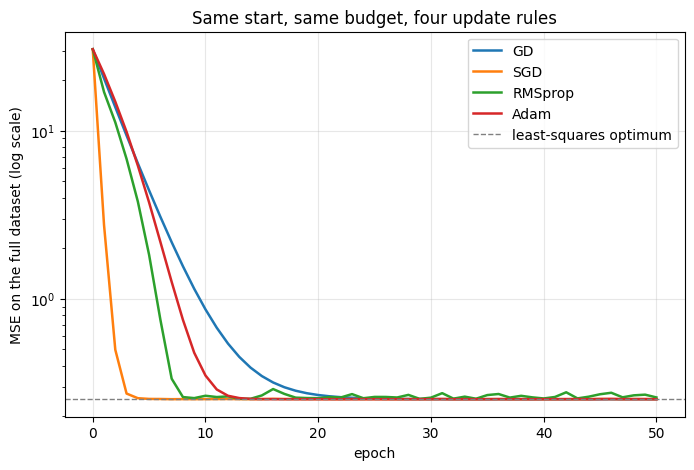

In [ ]:
plt.figure(figsize=(8, 5))
for name, curve in curves.items():
    plt.plot(curve, label=name, lw=1.8)
plt.axhline(best_loss, color="gray", ls="--", lw=1, label="least-squares optimum")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE on the full dataset (log scale)")
plt.title("Same start, same budget, four update rules")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

GD gets one update per epoch, the three stochastic methods get 13 (400 / 32) -
that alone explains most of the gap between the smooth blue curve and the rest.

Look at the tail as well: with a constant learning rate the mini-batch methods
never really settle, they hover just above the dashed line (most visibly
RMSprop, in green). Batch GD has no sampling noise to fight, so it slides
exactly onto the optimum - it just takes its time getting there.

### Where the adaptive methods actually earn their keep

On well-scaled data every method eventually gets there. The interesting case is
an **ill-conditioned** loss: two features on very different scales stretch the
bowl into a narrow valley. Now a single learning rate has to satisfy the steep
direction, so progress along the flat one becomes glacial - while RMSprop and
Adam, which rescale each coordinate by its own gradient history, walk almost
straight to the bottom.

In [ ]:
rng = np.random.default_rng(1)
X_ill = rng.normal(size=(200, 2)) * np.array([1.0, 0.1])   # 2nd feature 10x smaller
w_ill = np.array([2.0, -3.0])
y_ill = X_ill @ w_ill                                      # noise-free: minimum sits exactly at w_ill

eig = np.linalg.eigvalsh(2 * X_ill.T @ X_ill / len(y_ill))
print(f"curvature along the two axes: {eig[1]:.2f} vs {eig[0]:.3f}  ->  condition number {eig[1] / eig[0]:.0f}")

start = np.array([-3.0, 3.0])
paths = {
    "GD":      gradient_descent(X_ill, y_ill, start, lr=0.4, n_epochs=60)[1],
    "SGD":     sgd(X_ill, y_ill, start, lr=0.4, n_epochs=60, batch_size=BATCH)[1],
    "RMSprop": rmsprop(X_ill, y_ill, start, lr=0.1, n_epochs=60, batch_size=BATCH)[1],
    "Adam":    adam(X_ill, y_ill, start, lr=0.1, n_epochs=60, batch_size=BATCH)[1],
}
for name, path in paths.items():
    print(f"{name:<8} ended at w = [{path[-1, 0]:6.3f}, {path[-1, 1]:6.3f}]   loss = {mse_loss(path[-1], X_ill, y_ill):.2e}")

curvature along the two axes: 1.70 vs 0.016  ->  condition number 107
GD       ended at w = [ 2.065,  1.032]   loss = 1.30e-01
SGD      ended at w = [ 2.013, -2.605]   loss = 1.28e-03
RMSprop  ended at w = [ 2.005, -3.024]   loss = 2.78e-05
Adam     ended at w = [ 2.000, -3.000]   loss = 1.27e-09


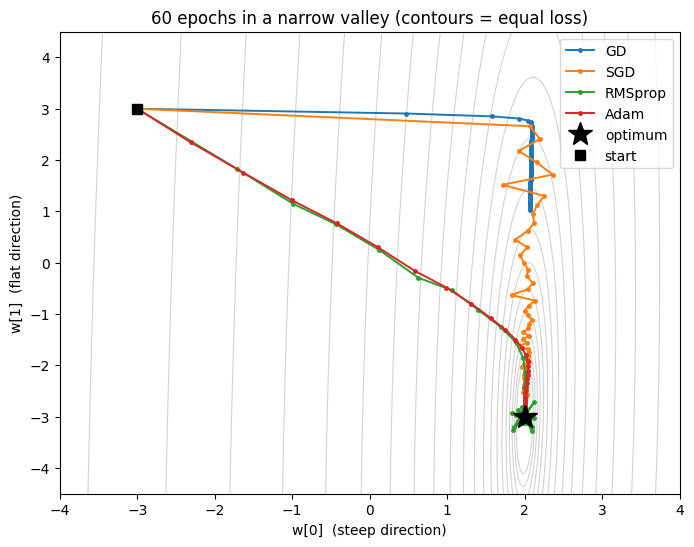

In [ ]:
gx, gy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4.5, 4.5, 300))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
Z = np.mean((grid @ X_ill.T - y_ill) ** 2, axis=1).reshape(gx.shape)

plt.figure(figsize=(8, 6))
plt.contour(gx, gy, Z, levels=np.logspace(-2, 1.6, 22), colors="lightgray", linewidths=0.8)
for name, path in paths.items():
    plt.plot(path[:, 0], path[:, 1], marker="o", ms=2.5, lw=1.4, label=name)
plt.plot(*w_ill, marker="*", ms=18, color="black", ls="", label="optimum")
plt.plot(*start, marker="s", ms=7, color="black", ls="", label="start")

plt.xlabel("w[0]  (steep direction)")
plt.ylabel("w[1]  (flat direction)")
plt.title("60 epochs in a narrow valley (contours = equal loss)")
plt.legend()
plt.show()

GD (blue) fixes the steep direction `w[0]` within a couple of epochs and then
inches along the flat one: 60 epochs later it is still sitting at `w[1] = 1.03`,
barely a third of the way down. SGD follows the same L-shaped route but covers
much more of it, simply because it takes 7 updates per epoch instead of 1 - and
you can see the sampling noise shaking its path.

RMSprop and Adam divide each coordinate by the size of its own recent gradients,
which stretches the tiny `w[1]` gradients back up to a usable scale. Their path
is a straight diagonal into the star, and Adam finishes with a loss of `1e-9`
against GD's `0.13`.

## Takeaways

* **GD** - exact gradient, smooth and predictable, one update per pass over the
  data. Fine for small problems, hopeless for big ones.
* **SGD** - swaps exactness for speed: noisy steps, many more of them. Still the
  backbone of deep learning (usually with momentum on top).
* **RMSprop** - per-coordinate step sizes from an EMA of squared gradients. Fixes
  badly scaled / ill-conditioned problems that a single lr cannot serve.
* **Adam** - momentum for the direction plus RMSprop for the step size, with a
  bias correction for the cold start. The sensible default when you do not want
  to spend time tuning.

Two knobs are worth remembering: **lr** decides everything (too big diverges, too
small crawls), and **batch_size** trades gradient quality against the number of
updates per epoch.